# Sample Coco Annotation Format  
  
[source](https://roboflow.com/formats/coco-json)  
  
```python
{
    "info": {
        "year": "2020",
        "version": "1",
        "description": "Exported from roboflow.ai",
        "contributor": "Roboflow",
        "url": "https://app.roboflow.ai/datasets/hard-hat-sample/1",
        "date_created": "2000-01-01T00:00:00+00:00"
    },
    "licenses": [
        {
            "id": 1,
            "url": "https://creativecommons.org/publicdomain/zero/1.0/",
            "name": "Public Domain"
        }
    ],
    "categories": [
        {
            "id": 0,
            "name": "Workers",
            "supercategory": "none"
        },
        {
            "id": 1,
            "name": "head",
            "supercategory": "Workers"
        },
        {
            "id": 2,
            "name": "helmet",
            "supercategory": "Workers"
        },
        {
            "id": 3,
            "name": "person",
            "supercategory": "Workers"
        }
    ],
    "images": [
        {
            "id": 0,
            "license": 1,
            "file_name": "0001.jpg",
            "height": 275,
            "width": 490,
            "date_captured": "2020-07-20T19:39:26+00:00"
        }
    ],
    "annotations": [
        {
            "id": 0,
            "image_id": 0,
            "category_id": 2,
            "bbox": [ 45, 2, 85, 85 ],
            "area": 7225,
            "segmentation": [],
            "iscrowd": 0
        },
        {
            "id": 1,
            "image_id": 0,
            "category_id": 2,
            "bbox": [ 324, 29, 72, 81 ],
            "area": 5832,
            "segmentation": [],
            "iscrowd": 0
        }
    ]
}
```

# Installing Package

In [ ]:
!pip3 uninstall ctu -y

In [ ]:
# %cd /home/ec2-user/SageMaker/coco-transform-util/
# !python3 setup.py install > /dev/null

In [1]:
import sys

sys.path.append("../../")

In [2]:
# Importing relevant functions
from ctu import (
    sample_modif_step_di, get_modif_image, get_modif_coco_annotation, 
    accept_and_process_modif_di, ImgTransform, Visualize
)

from ctu import (
    WholeCoco2SingleImgCoco, CocoAbsoluteToRelative, CocoRel2CocoSpecificSize
)

import ctu
print('\nPackage Version:', ctu.__version__)

print('Success')


Package Version: 0.3.0
Success


# Example: Using Transformation Dictionary

In [1]:
from examples.scripts.example_highlevel_function import run

run()

ModuleNotFoundError: No module named 'examples.scripts'

# Example: Using the Core Modules 


Original


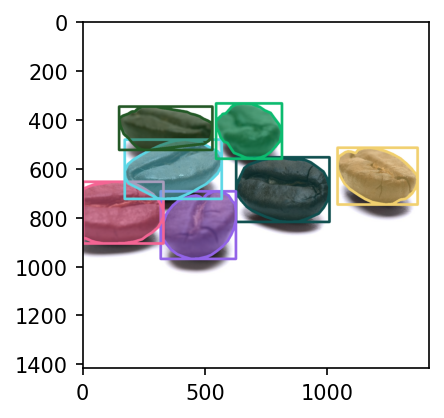


Rescaling image size (With Aspect Ratio)


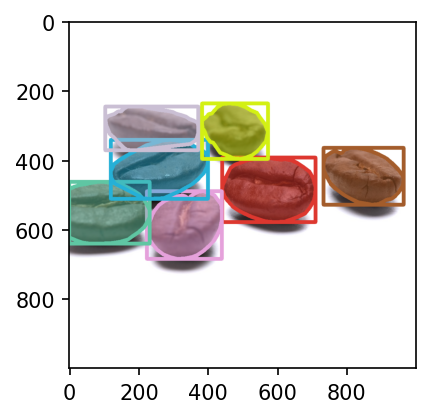


Rescaling image size (Without Aspect Ratio)


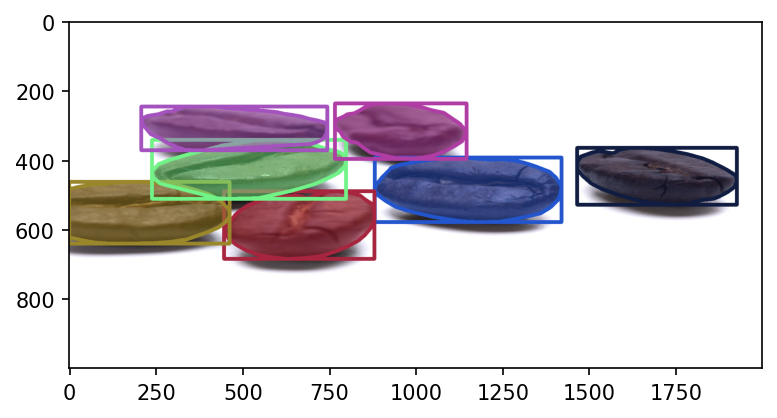


Rescaling image size + add padding to the image


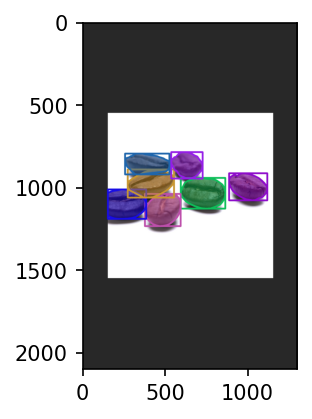


Rescaling image size + cropping the image & maintaining the annotation


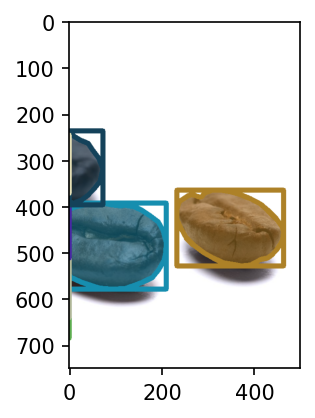


Rescaling image size + add padding to the image + cropping the image & maintaining the annotation


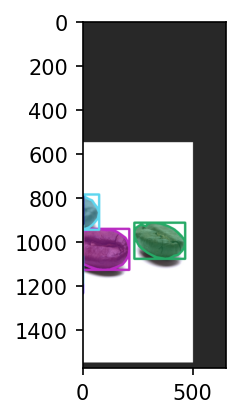

In [3]:
from examples.scripts.example_core_modules import run

run()

Following Setting is being used:
	image_path	: /home/mohit/Documents/new_age/coco-transformation-util/examples/datasets/mini/lemon.jpeg
	aspect_ratio	: dont maintain
	image_ht_wd	: (1000, 1500)
	padding_ht_wd	: None
	padding_color	: (10, 10, 10)
	crop_pt1_pt2	: ((0.25, 0.25), (0.75, 0.75))
	img_name	: lemon.jpeg


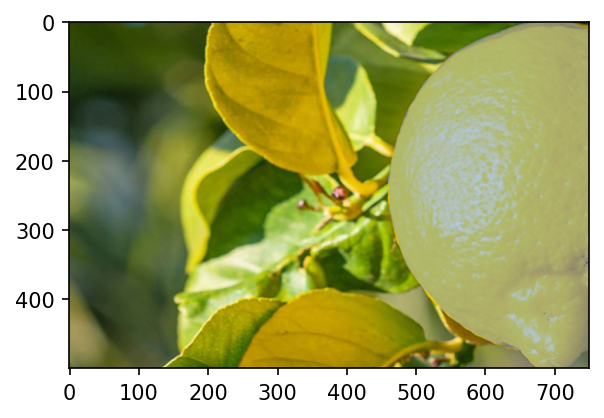

In [4]:
from examples.scripts.example_highlevel_function_createmask import run

run()

In [2]:

import os
from pathlib import Path
import cv2
import random
import ctu
import glob


examples_dir = "/home/mohit/Documents/new_age/coco-transformation-util/examples"
dataset_dir = os.path.join(examples_dir, "datasets", "mini")
coco_path = os.path.join(dataset_dir, "coco-annotation.json")

# collect images recursively
print(glob.glob(dataset_dir, recursive=True)[:3])
image_paths = [
    path
    for path in glob.glob(dataset_dir + "/**/*", recursive=True)
    if path.endswith((".jpg", ".jpeg", ".png"))
]
# for ext in ("*.jpg", "*.jpeg", "*.png"):
#     image_paths.extend((dataset_dir).rglob(ext))
# image_paths = sorted([str(p) for p in image_paths])

if len(image_paths) == 0:
    raise Exception(f'No images detected in the directory: {dataset_dir}')


['/home/mohit/Documents/new_age/coco-transformation-util/examples/datasets/mini']


In [3]:
path = image_paths[min(2, len(image_paths)-1)]
path

'/home/mohit/Documents/new_age/coco-transformation-util/examples/datasets/mini/Mangoes.jpeg'

Following Setting is being used:
	image_path	: /home/mohit/Documents/new_age/coco-transformation-util/examples/datasets/mini/Mangoes.jpeg
	aspect_ratio	: dont maintain
	image_ht_wd	: (1000, 1500)
	padding_ht_wd	: None
	padding_color	: (10, 10, 10)
	crop_pt1_pt2	: ((0.25, 0.25), (0.75, 0.75))
	img_name	: Mangoes.jpeg


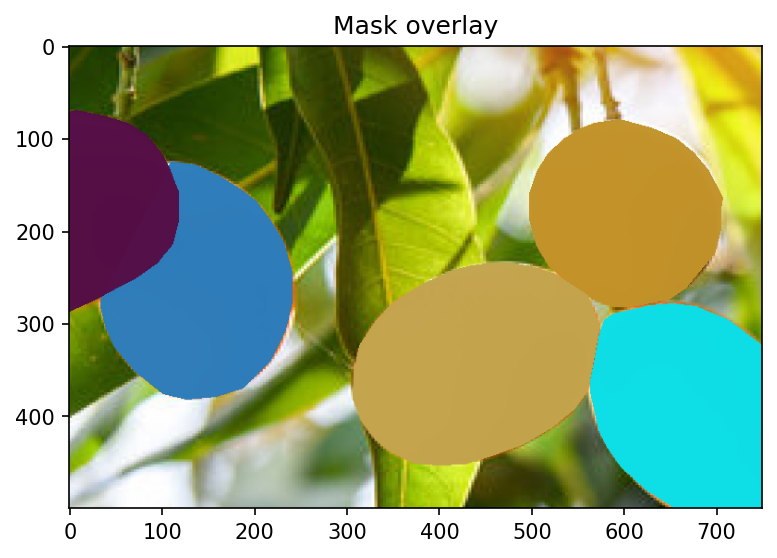

0


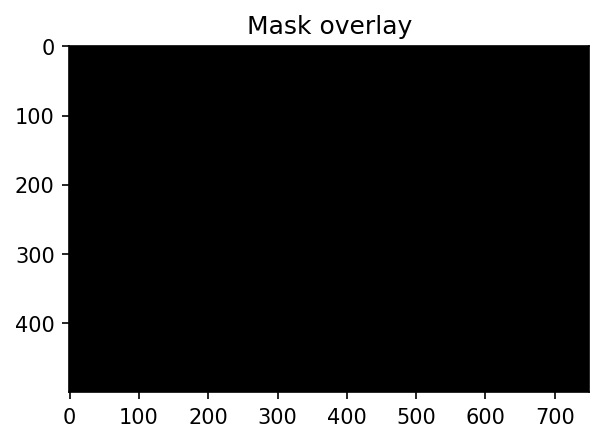

In [ ]:


# reading the image
modif_di = {
    "image_path": path,
    "aspect_ratio": "dont maintain",
    # "options: None, 'maintain', 'dont maintain'",
    "image_ht_wd": (1000, 1500),
    # (1500, 2000),
    "padding_ht_wd": None,# (0.15,0.15),
    # "eg: None, (0.15,0.15)",
    "padding_color": (10, 10, 10),
    "crop_pt1_pt2": ((0.25,0.25), (0.75,0.75)),
    # "eg: None, ((0.1,0.1), (0.9,0.9))"
}

modif_di = ctu.normalize_modification_spec(modif_di)
img = ctu.get_modified_image(modif_di)
anno = ctu.get_modified_coco_annotation(img, str(coco_path), modif_di)

ctu.AnnotationVisualizer.draw_annotation(
    img,
    coco_ann_di=anno,
    cls_mapper_di=None,
    draw_what=["mask"], # "bbox", "polyline", 
    thickness=100,
    alpha=0.98,
    title="Mask overlay",
    figure_size=(8, 4)
)

# print(anno)

# creating a mask
poly = anno["annotations"][0]["segmentation"]
mask = ctu.create_mask(img, poly, transparent_mask=True)
# visualize or save as needed

mask = ctu.create_mask(img, poly, category_fill_value=0, transparent_mask=False)
# visualize or save as needed

print(mask.sum().sum())

ctu.AnnotationVisualizer()._view_img_using_matplot(mask*250, title="Mask overlay")


In [9]:
# anno["annotations"][0]["segmentation"]

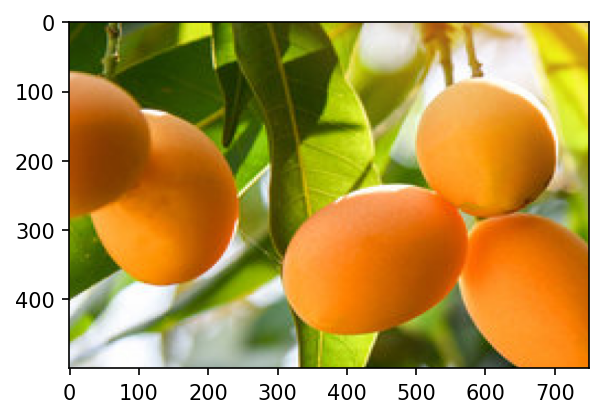

In [ ]:

ctu.Visualize.draw_annotation(
    img, None, draw_what=["mask"]
)
